In [1]:
from coffea import processor
from coffea.nanoevents import NanoAODSchema, NanoEventsFactory
from constructors.filesets import BuildFileset, rucio_queries, filesets
from constructors.corrections.sets import corrections
from loadmodule import loadModule
from dask.distributed import Client
import mplhep as hep
import matplotlib.pyplot as plt
from constructors.utils import UtilFunctions as UF
client = Client("tls://localhost:8786") #load local dask client (HTCondor) coffea-casa
MuonProcessor = loadModule("constructors/processors/muon_processor.py") #load processor instance through absolute path
test_fileset = getattr(filesets,'test_fileset')
fileset = UF().loadJson("constructors/filesets/ZToMuMu_fileset.json")

In [2]:
%%time
dask_run = processor.Runner( #this is new runner function for coffea 2025.10
    executor=processor.DaskExecutor(client=client, compression=None), #execute via dask workers
    schema=NanoAODSchema,
    chunksize=100_000,
    skipbadfiles=True,
    savemetrics=False,
)
year = "2022"
#histograms = dask_run(test_fileset, processor_instance=MuonProcessor(year, corrections.corr_dict(year)))
histograms = dask_run(fileset, processor_instance=MuonProcessor(year, corrections.corr_dict(year)))

Output()

Output()

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



CPU times: user 3min 33s, sys: 10 s, total: 3min 43s
Wall time: 1h 22min 4s


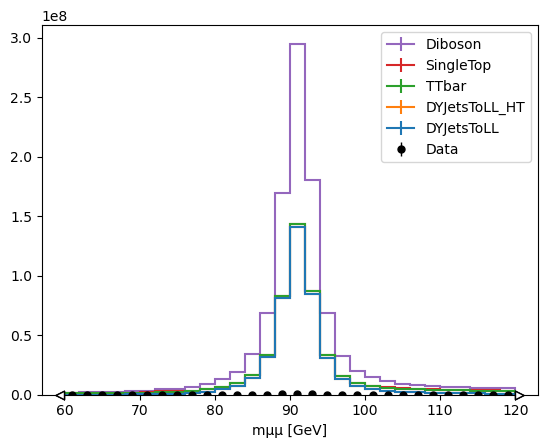

In [4]:
bkg = ["DYJetsToLL", "DYJetsToLL_HT", "TTbar", "SingleTop", "Diboson"]
data = ["DoubleMuon", "SingleMuon", "EGamma", "Muon"]

bkg_hists = [histograms[p]["mass"] for p in bkg]
data_hist = sum(histograms[p]["mass"] for p in data)

hep.histplot(bkg_hists, stack=True, label=bkg)
hep.histplot(data_hist,histtype="errorbar",label="Data",color="black")

plt.legend()
plt.show()

## To generate rucio fileset

In [ ]:
%%time
query_name = 'ZToMuMu'
testFileset = getattr(filesets,'test_fileset') #load test fileset
rucioQuery = getattr(rucio_queries, query_name) #load rucio_query for ZToMuMu files
fileset = BuildFileset().buildFileset(rucioQuery,query_name); #build fileset with DataDiscoveryCLI and convert
                                                              #internally filesets_vailable.json.gz to python dict